<a href="https://colab.research.google.com/github/fatoufall737/atelier_matplotlib_iot.ipynb/blob/main/atelier_matplotlib_iot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Contexte
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT.
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression,
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure.
Après avoir utilisé NumPy pour manipuler les données numériques et Pandas pour importer,
nettoyer et analyser le dataset, l'étape suivante consiste à représenter graphiquement les
informations afin d'identifier des tendances, des différences entre bâtiments et des anomalies.
Structure du projet
1) Structurer le projet comme suit :
atelier_matplotlib_iot/
│
├── data/
│   
└── mesures_capteurs.csv
│    
├── notebooks/
│   
└── atelier_matplotlib_iot.ipynb
│
└── exports/
├── temperature.png
└── temperature.pdf
2) Stocker le fichier fourni mesures_capteurs.csv dans le sous-dossier data
3) Créer le notebook atelier_matplotlib_iot.ipynb
4) Installer et importer matplotlib et pandas
5) Importer mesures_capteurs.csv dans le dataframe df

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()  #  je sélectionne mesures_capteurs.csv depuis mon ordinateur

Saving mesures_capteurs.csv to mesures_capteurs.csv


In [3]:
# Importer mesures_capteurs.csv dans le dataframe df
df = pd.read_csv("mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


Partie 1 – Graphique linéaire (Line Plot)
1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende
et la grille.
2) Identifier visuellement les valeurs qui semblent anormales.

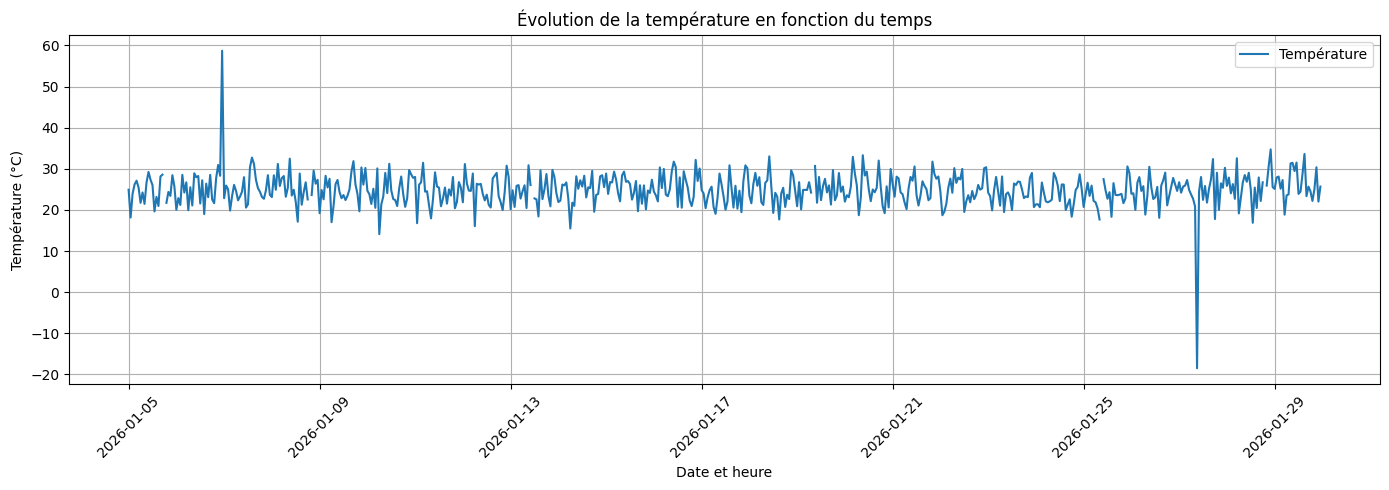

In [6]:
# 1) Évolution de la température en fonction du temps
df["date_heure"] = pd.to_datetime(df["date_heure"])
df = df.sort_values(by="date_heure")  # trier par ordre chronologique

plt.figure(figsize=(14, 5))
plt.plot(df["date_heure"], df["temperature"], label="Température")
plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**2) Observation visuelle des anomalies**

Deux valeurs sortent clairement de la courbe :
- un pic vers 55-60°C
- un creux vers -20°C

Le reste des températures reste normal, entre 15°C et 35°C. Ces deux valeurs sont probablement des erreurs de capteur.

Partie 2 – Diagramme en barres (Bar Chart)
1) Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments
2) Comparer graphiquement la consommation moyenne des bâtiments
3) Comparer la consommation moyenne des bâtiments avec un graphique horizontal
4) Dans quels cas un graphique horizontal peut-il être plus lisible ?

In [7]:
# 1) Consommation moyenne par bâtiment
consommation_batiment = df.groupby("batiment")["consommation"].mean()
consommation_batiment

,consommation
batiment,
B001,177.870927
B002,221.785333
B003,153.191000
B004,282.552282


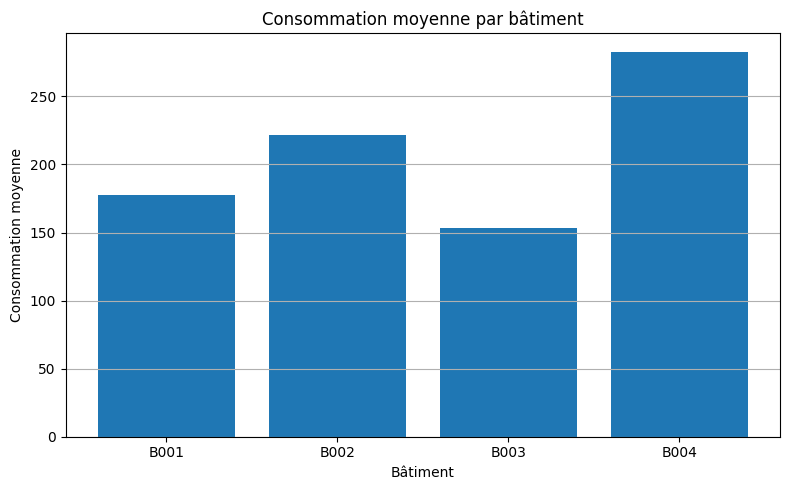

In [8]:
# 2) Comparaison graphique de la consommation moyenne des bâtiments
plt.figure(figsize=(8, 5))
plt.bar(consommation_batiment.index, consommation_batiment.values)
plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Consommation moyenne")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

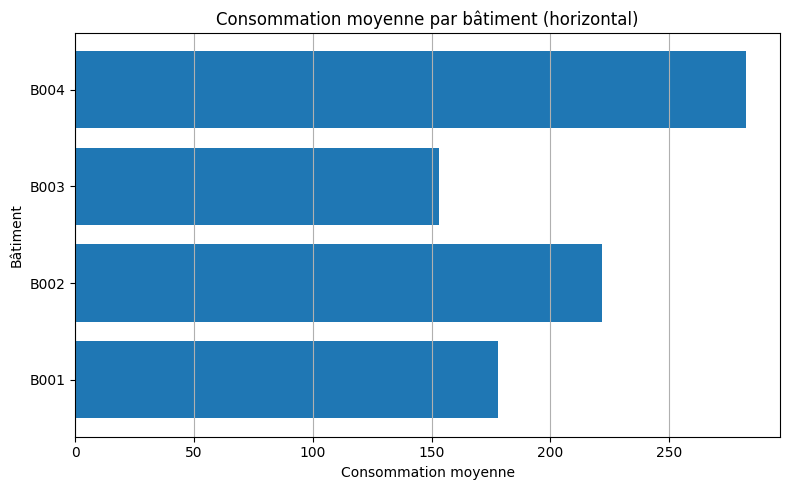

In [9]:
# 3) Comparaison avec un graphique horizontal
plt.figure(figsize=(8, 5))
plt.barh(consommation_batiment.index, consommation_batiment.values)
plt.title("Consommation moyenne par bâtiment (horizontal)")
plt.xlabel("Consommation moyenne")
plt.ylabel("Bâtiment")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

**4) Quand un graphique horizontal est plus lisible**

Un graphique horizontal est utile quand :
- les noms des catégories sont longs (ils tiennent mieux sur l'axe vertical que penchés sur l'axe horizontal)
- il y a beaucoup de catégories à comparer (plus facile à lire de haut en bas que côte à côte)
- on veut classer les barres facilement du plus grand au plus petit, du haut vers le bas

Partie 3 – Histogramme
1) Afficher la distribution des températures en divisant la plage des données en 20 classes et en
affichant uniquement les lignes horizontales de la grille
2) Analyser le graphique pour voir
1/2
a) où se concentrent les températures ;  
b) si la distribution semble symétrique ;  
c) s'il existe des valeurs très éloignées ;  
d) si des valeurs aberrantes sont visibles.
3) Afficher la distribution de la consommation en divisant la plage des données en 20 classes
a) Modifier le nombre de classes à 10
b) Modifier le nombre de classes à 30
c) Quel impact le nombre de classes a-t-il sur l'interprétation ?

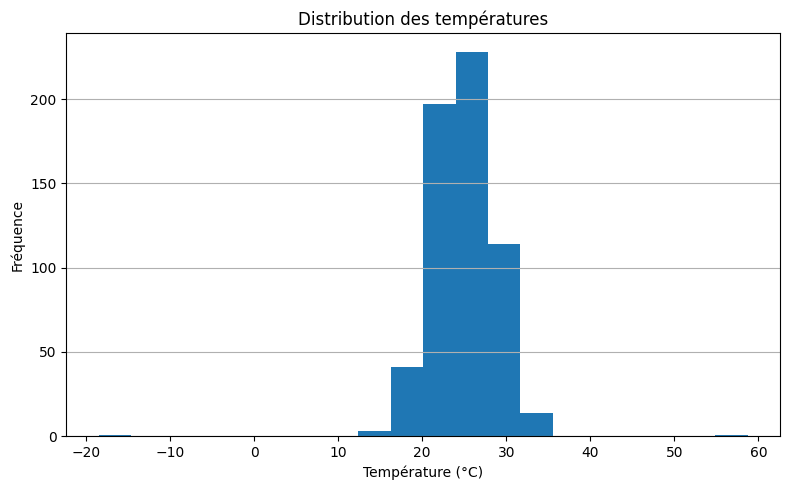

In [10]:
# 1) Distribution des températures (20 classes)
plt.figure(figsize=(8, 5))
plt.hist(df["temperature"].dropna(), bins=20)
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**2) Analyse de l'histogramme**

- La plupart des températures sont entre 15°C et 35°C.
- Le pic le plus haut est vers 20-25°C, c'est la température la plus fréquente.
- Le graphique a une forme de cloche, assez équilibrée des deux côtés.
- Deux petites barres sont très loin des autres : une vers -20°C et une vers 58°C.
- Ces deux valeurs sont anormales, ce sont les mêmes erreurs de capteur vues dans la Partie 1.

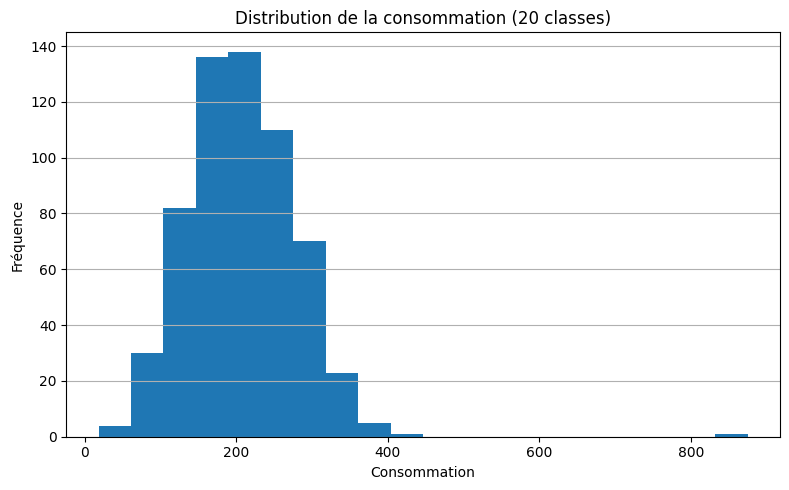

In [11]:
# 3) Distribution de la consommation (20 classes)
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=20)
plt.title("Distribution de la consommation (20 classes)")
plt.xlabel("Consommation")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

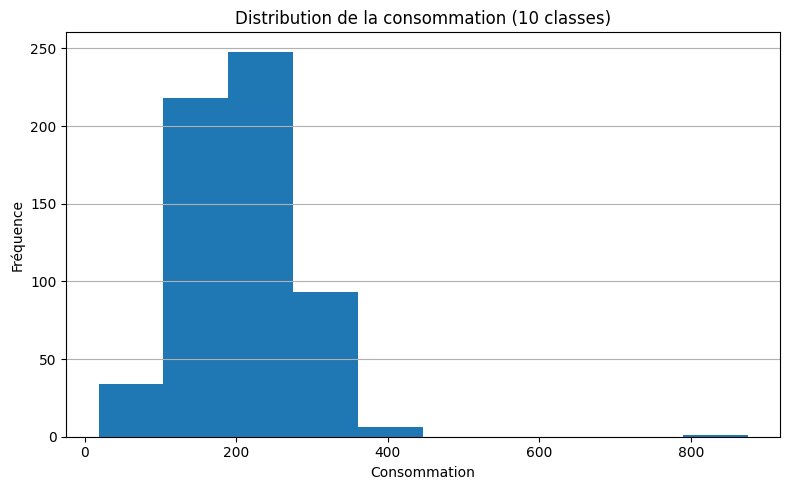

In [12]:
# 3a) Distribution de la consommation (10 classes)
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=10)
plt.title("Distribution de la consommation (10 classes)")
plt.xlabel("Consommation")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

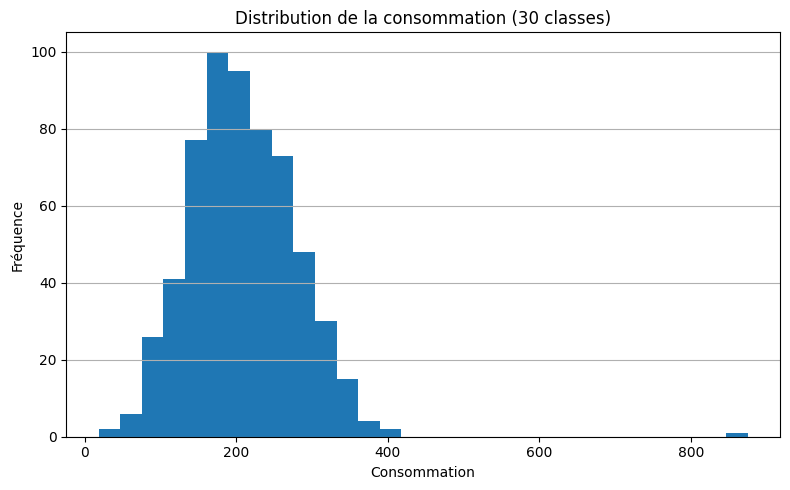

In [13]:
# 3b) Distribution de la consommation (30 classes)
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=30)
plt.title("Distribution de la consommation (30 classes)")
plt.xlabel("Consommation")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**3c) Impact du nombre de classes**

- Avec peu de classes (10), le graphique est plus lisse et facile à lire, mais on perd des détails.
- Avec beaucoup de classes (30), le graphique montre plus de détails, mais devient plus difficile à lire (trop de petites variations).
- Le nombre de classes doit être choisi selon ce qu'on veut voir : une vue générale (peu de classes) ou une vue précise (beaucoup de classes).